In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
clinical = pd.read_csv(
    "../data/processed/tcga_brca_clinical_clean.csv"
)

clinical.head()

,case_id,patient_id,sex,race,ethnicity,age_at_diagnosis_days,age_at_diagnosis_years,primary_diagnosis,stage,pathologic_T,pathologic_N,pathologic_M,vital_status,days_to_death,latest_follow_up_days,overall_survival_days,overall_survival_event
0,001cef41-ff86-4d3f-a140-a647ac4b10a1,TCGA-E2-A1IU,female,white,not hispanic or latino,22279.0,60.996578,"Infiltrating duct carcinoma, NOS",Stage IA,T1c,N0 (mol+),M0,Alive,NaN,337.0,337.0,0.0
1,0045349c-69d9-4306-a403-c9c1fa836644,TCGA-A1-A0SB,female,white,not hispanic or latino,25833.0,70.726899,Adenoid cystic carcinoma,Stage I,T1c,N0,M0,Alive,NaN,259.0,259.0,0.0
2,00807dae-9f4a-4fd1-aac2-82eb11bf2afb,TCGA-A2-A04W,female,white,not hispanic or latino,18345.0,50.225873,Apocrine adenocarcinoma,Stage IIB,T2,N1mi,M0,Alive,NaN,3102.0,3102.0,0.0
3,00a2d166-78c9-4687-a195-3d6315c27574,TCGA-AN-A0AM,female,white,not hispanic or latino,20713.0,56.709103,"Infiltrating duct carcinoma, NOS",Stage IIA,T2,N0,M0,Alive,NaN,5.0,5.0,0.0
4,00b11ca8-8540-4a3d-b602-ec754b00230b,TCGA-LL-A440,female,white,not hispanic or latino,22497.0,61.593429,"Lobular carcinoma, NOS",Stage IA,T1c,N0 (i-),MX,Alive,NaN,759.0,759.0,0.0


In [3]:
print("Shape:", clinical.shape)
print("Unique patients:", clinical["patient_id"].nunique())

Shape: (1098, 17)
Unique patients: 1098


In [4]:
clinical[
    [
        "age_at_diagnosis_years",
        "vital_status",
        "stage",
        "primary_diagnosis"
    ]
].describe(include="all")

,age_at_diagnosis_years,vital_status,stage,primary_diagnosis
count,1082.000000,1097,1086,1097
unique,NaN,2,12,22
top,NaN,Alive,Stage IIA,"Infiltrating duct carcinoma, NOS"
freq,NaN,945,358,778
mean,59.101550,NaN,NaN,NaN
std,13.180320,NaN,NaN,NaN
min,26.573580,NaN,NaN,NaN
25%,49.358658,NaN,NaN,NaN
50%,59.029432,NaN,NaN,NaN
75%,68.086927,NaN,NaN,NaN


In [5]:
print("Median age:",
      clinical["age_at_diagnosis_years"].median())

print("Age range:",
      clinical["age_at_diagnosis_years"].min(),
      "-",
      clinical["age_at_diagnosis_years"].max())

Median age: 59.02943189596167
Age range: 26.573579739904176 - 89.99863107460644


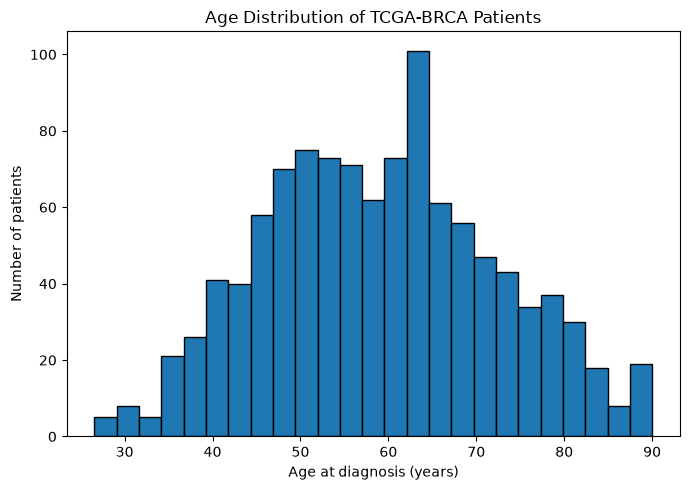

In [6]:
plt.figure(figsize=(7, 5))

plt.hist(
    clinical["age_at_diagnosis_years"].dropna(),
    bins=25,
    edgecolor="black"
)

plt.xlabel("Age at diagnosis (years)")
plt.ylabel("Number of patients")
plt.title("Age Distribution of TCGA-BRCA Patients")

plt.tight_layout()
plt.show()

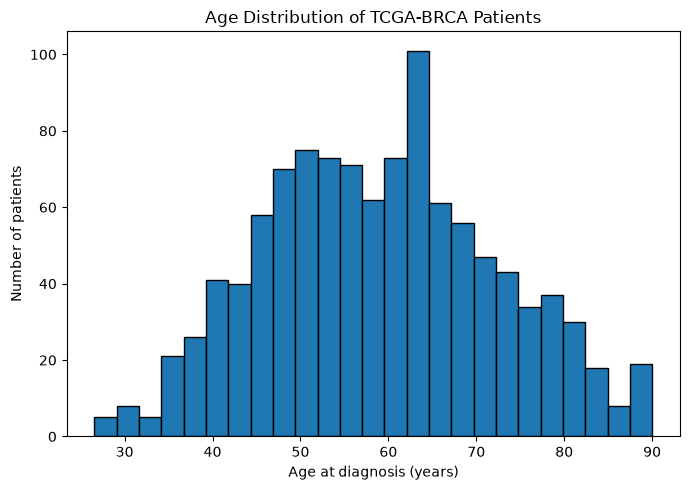

In [7]:
figures_dir = Path("../figures")
figures_dir.mkdir(exist_ok=True)

plt.figure(figsize=(7, 5))

plt.hist(
    clinical["age_at_diagnosis_years"].dropna(),
    bins=25,
    edgecolor="black"
)

plt.xlabel("Age at diagnosis (years)")
plt.ylabel("Number of patients")
plt.title("Age Distribution of TCGA-BRCA Patients")

plt.tight_layout()

plt.savefig(
    figures_dir / "age_distribution_clean.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [8]:
clinical["stage"].value_counts(dropna=False)

stage
Stage IIA     358
Stage IIB     257
Stage IIIA    155
Stage I        90
Stage IA       86
Stage IIIC     65
Stage IIIB     27
Stage IV       20
Stage X        13
NaN            12
Stage IB        7
Stage II        6
Stage III       2
Name: count, dtype: int64

In [9]:
def simplify_stage(stage):
    if pd.isna(stage):
        return pd.NA

    stage = str(stage).strip()

    if stage in ["Stage I", "Stage IA", "Stage IB"]:
        return "Stage I"

    elif stage in ["Stage II", "Stage IIA", "Stage IIB"]:
        return "Stage II"

    elif stage in ["Stage III", "Stage IIIA", "Stage IIIB", "Stage IIIC"]:
        return "Stage III"

    elif stage == "Stage IV":
        return "Stage IV"

    else:
        return pd.NA


clinical["stage_group"] = clinical["stage"].apply(simplify_stage)

In [10]:
clinical["stage_group"].value_counts(dropna=False)

stage_group
Stage II     621
Stage III    249
Stage I      183
<NA>          25
Stage IV      20
Name: count, dtype: int64

In [11]:
stage_summary = (
    clinical["stage_group"]
    .value_counts()
    .reindex(["Stage I", "Stage II", "Stage III", "Stage IV"])
    .to_frame("n")
)

stage_summary["percent"] = (
    stage_summary["n"] / clinical["stage_group"].notna().sum() * 100
)

stage_summary

,n,percent
stage_group,,
Stage I,183,17.054986
Stage II,621,57.875116
Stage III,249,23.205965
Stage IV,20,1.863933


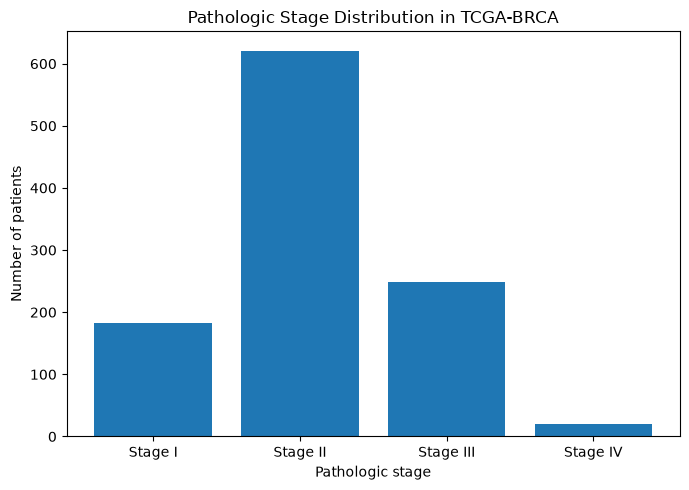

In [12]:
stage_order = ["Stage I", "Stage II", "Stage III", "Stage IV"]

stage_counts = (
    clinical["stage_group"]
    .value_counts()
    .reindex(stage_order)
)

plt.figure(figsize=(7, 5))

plt.bar(
    stage_counts.index,
    stage_counts.values
)

plt.xlabel("Pathologic stage")
plt.ylabel("Number of patients")
plt.title("Pathologic Stage Distribution in TCGA-BRCA")

plt.tight_layout()
plt.show()

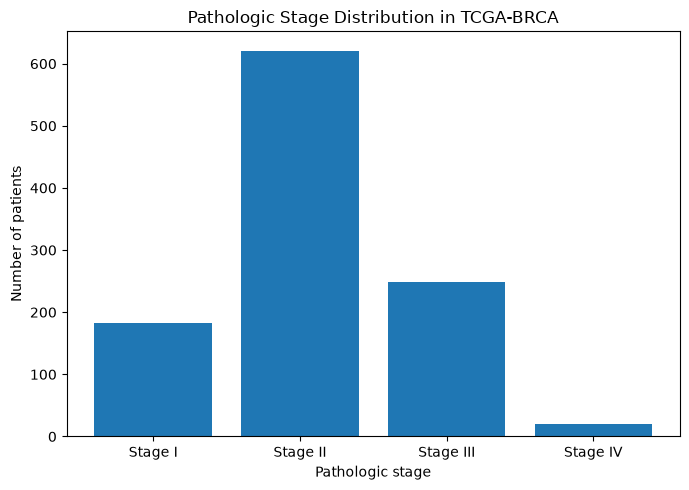

In [13]:
plt.figure(figsize=(7, 5))

plt.bar(
    stage_counts.index,
    stage_counts.values
)

plt.xlabel("Pathologic stage")
plt.ylabel("Number of patients")
plt.title("Pathologic Stage Distribution in TCGA-BRCA")

plt.tight_layout()

plt.savefig(
    figures_dir / "clinical_stage_distribution_clean.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
clinical["primary_diagnosis"].value_counts(dropna=False)

primary_diagnosis
Infiltrating duct carcinoma, NOS                            778
Lobular carcinoma, NOS                                      201
Infiltrating duct and lobular carcinoma                      28
Infiltrating duct mixed with other types of carcinoma        19
Mucinous adenocarcinoma                                      16
Metaplastic carcinoma, NOS                                   14
Infiltrating lobular mixed with other types of carcinoma      7
Intraductal papillary adenocarcinoma with invasion            6
Medullary carcinoma, NOS                                      6
Invasive micropapillary carcinoma                             4
Pleomorphic carcinoma                                         3
Paget disease and infiltrating duct carcinoma of breast       3
Phyllodes tumor, malignant                                    2
Papillary carcinoma, NOS                                      2
Carcinoma, NOS                                                1
Adenoid cystic carcino

In [15]:
def simplify_diagnosis(diagnosis):
    if pd.isna(diagnosis):
        return pd.NA

    if diagnosis == "Infiltrating duct carcinoma, NOS":
        return "Ductal"

    elif diagnosis == "Lobular carcinoma, NOS":
        return "Lobular"

    elif diagnosis == "Infiltrating duct and lobular carcinoma":
        return "Mixed ductal/lobular"

    else:
        return "Other"


clinical["diagnosis_group"] = (
    clinical["primary_diagnosis"]
    .apply(simplify_diagnosis)
)

In [16]:
clinical["diagnosis_group"].value_counts(dropna=False)

diagnosis_group
Ductal                  778
Lobular                 201
Other                    90
Mixed ductal/lobular     28
<NA>                      1
Name: count, dtype: int64

In [17]:
diagnosis_order = [
    "Ductal",
    "Lobular",
    "Mixed ductal/lobular",
    "Other"
]

diagnosis_summary = (
    clinical["diagnosis_group"]
    .value_counts()
    .reindex(diagnosis_order)
    .to_frame("n")
)

diagnosis_summary["percent"] = (
    diagnosis_summary["n"]
    / clinical["diagnosis_group"].notna().sum()
    * 100
)

diagnosis_summary

,n,percent
diagnosis_group,,
Ductal,778,70.920693
Lobular,201,18.322698
Mixed ductal/lobular,28,2.552416
Other,90,8.204193


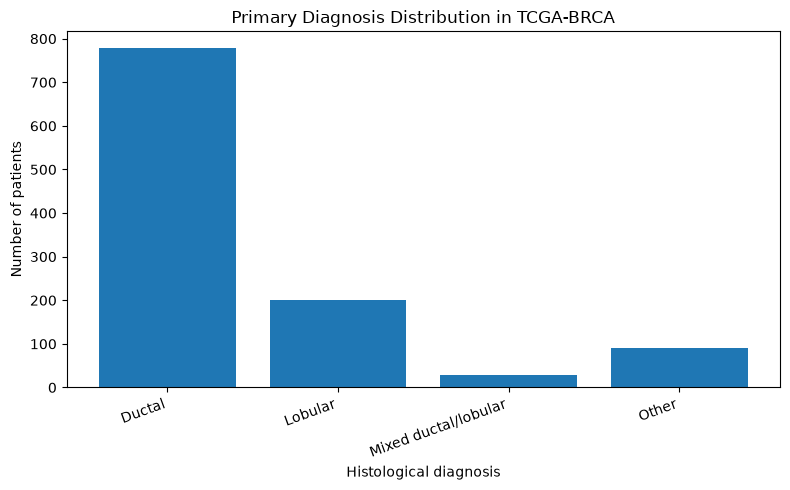

In [18]:
diagnosis_counts = (
    clinical["diagnosis_group"]
    .value_counts()
    .reindex(diagnosis_order)
)

plt.figure(figsize=(8, 5))

plt.bar(
    diagnosis_counts.index,
    diagnosis_counts.values
)

plt.xlabel("Histological diagnosis")
plt.ylabel("Number of patients")
plt.title("Primary Diagnosis Distribution in TCGA-BRCA")

plt.xticks(rotation=20, ha="right")

plt.tight_layout()
plt.show()

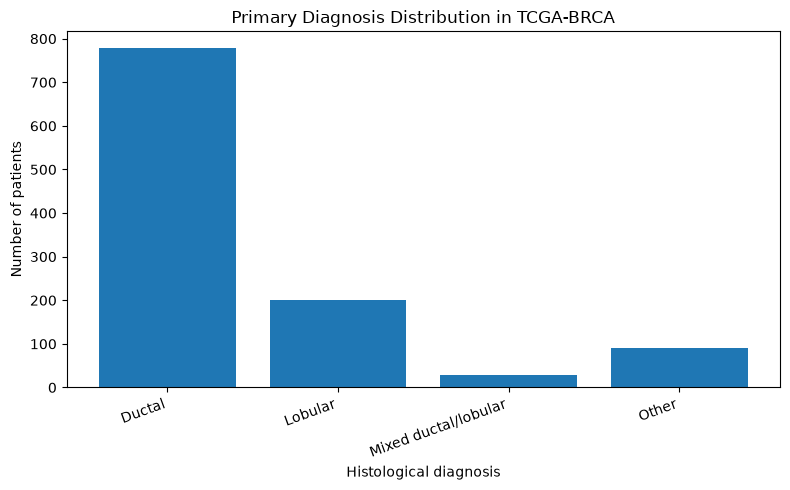

In [19]:
plt.figure(figsize=(8, 5))

plt.bar(
    diagnosis_counts.index,
    diagnosis_counts.values
)

plt.xlabel("Histological diagnosis")
plt.ylabel("Number of patients")
plt.title("Primary Diagnosis Distribution in TCGA-BRCA")

plt.xticks(rotation=20, ha="right")

plt.tight_layout()

plt.savefig(
    figures_dir / "primary_diagnosis_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
clinical["vital_status"].value_counts(dropna=False)

vital_status
Alive    945
Dead     152
NaN        1
Name: count, dtype: int64

In [21]:
vital_summary = (
    clinical["vital_status"]
    .value_counts()
    .reindex(["Alive", "Dead"])
    .to_frame("n")
)

vital_summary["percent"] = (
    vital_summary["n"]
    / clinical["vital_status"].notna().sum()
    * 100
)

vital_summary

,n,percent
vital_status,,
Alive,945,86.144029
Dead,152,13.855971


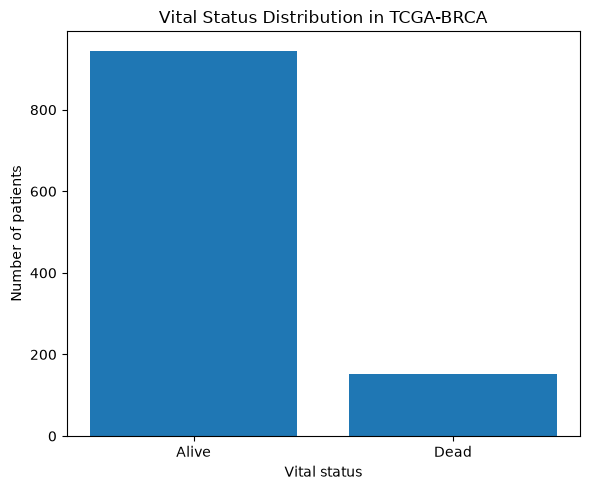

In [22]:
vital_counts = (
    clinical["vital_status"]
    .value_counts()
    .reindex(["Alive", "Dead"])
)

plt.figure(figsize=(6, 5))

plt.bar(
    vital_counts.index,
    vital_counts.values
)

plt.xlabel("Vital status")
plt.ylabel("Number of patients")
plt.title("Vital Status Distribution in TCGA-BRCA")

plt.tight_layout()
plt.show()

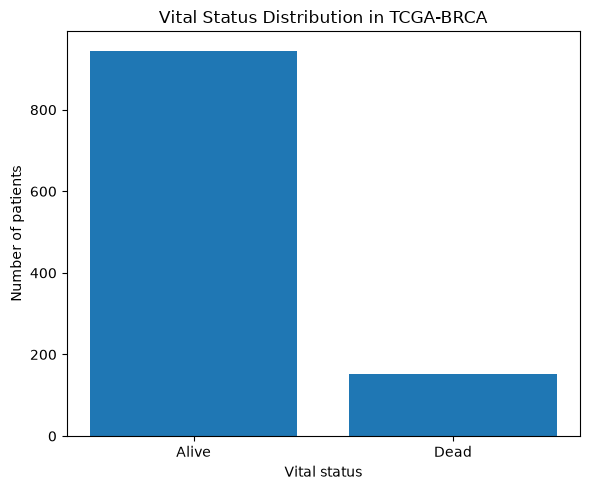

In [23]:
plt.figure(figsize=(6, 5))

plt.bar(
    vital_counts.index,
    vital_counts.values
)

plt.xlabel("Vital status")
plt.ylabel("Number of patients")
plt.title("Vital Status Distribution in TCGA-BRCA")

plt.tight_layout()

plt.savefig(
    figures_dir / "vital_status_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
cohort_summary = pd.DataFrame({
    "Characteristic": [
        "Total patients",
        "Age at diagnosis, median (years)",
        "Stage I",
        "Stage II",
        "Stage III",
        "Stage IV",
        "Ductal carcinoma",
        "Lobular carcinoma",
        "Mixed ductal/lobular carcinoma",
        "Other histological types",
        "Alive",
        "Dead",
        "Patients usable for survival analysis"
    ],

    "Value": [
        len(clinical),
        round(clinical["age_at_diagnosis_years"].median(), 1),
        (clinical["stage_group"] == "Stage I").sum(),
        (clinical["stage_group"] == "Stage II").sum(),
        (clinical["stage_group"] == "Stage III").sum(),
        (clinical["stage_group"] == "Stage IV").sum(),
        (clinical["diagnosis_group"] == "Ductal").sum(),
        (clinical["diagnosis_group"] == "Lobular").sum(),
        (clinical["diagnosis_group"] == "Mixed ductal/lobular").sum(),
        (clinical["diagnosis_group"] == "Other").sum(),
        (clinical["vital_status"] == "Alive").sum(),
        (clinical["vital_status"] == "Dead").sum(),
        (
            clinical["overall_survival_days"].notna()
            & clinical["overall_survival_event"].notna()
        ).sum()
    ]
})

cohort_summary

,Characteristic,Value
0,Total patients,1098.0
1,"Age at diagnosis, median (years)",59.0
2,Stage I,183.0
3,Stage II,621.0
4,Stage III,249.0
5,Stage IV,20.0
6,Ductal carcinoma,778.0
7,Lobular carcinoma,201.0
8,Mixed ductal/lobular carcinoma,28.0
9,Other histological types,90.0


In [25]:
results_dir = Path("../results")
results_dir.mkdir(exist_ok=True)

cohort_summary.to_csv(
    results_dir / "clinical_cohort_summary.csv",
    index=False
)

print("Saved:", results_dir / "clinical_cohort_summary.csv")

Saved: ../results/clinical_cohort_summary.csv


In [26]:
print(
    (results_dir / "clinical_cohort_summary.csv").exists()
)

True
